# Granger Causality Check: Winter AO and September Sea Ice Extent

This project asks one specific question. Does the winter Arctic Oscillation, a
measure of atmospheric pressure patterns over the Arctic, carry information that
helps predict September sea ice extent, beyond what the ice record itself already
tells you.

The test used here is Granger causality. It asks whether knowing the past values of
one series improves a prediction of another series, beyond what that series' own
past already gives. It is a standard, widely used test, and a natural first tool to
reach for on a question like this.

A related project used a different and more careful method called PCMCI to ask a
similar question. Running Granger causality here gives a direct, hands on comparison
point against that method, since PCMCI was built specifically to avoid some of the
mistakes that plain Granger causality is known to make, such as being fooled by a
shared trend between two series rather than a real link.

## Setup

Two tools are needed. grangercausalitytests runs the actual causality test.
adfuller checks whether a series is stationary, meaning it has no strong trend and
roughly constant variance over time.

Stationarity matters because Granger causality assumes it. If a series has a strong
trend, the test can find a false relationship, since two series that are both
trending will often look statistically linked even when nothing about them is
actually connected. So stationarity gets checked first, before any causality claim
gets made.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

## Data

NOAA sea ice extent and AO index, 1980 to 2025, 45 rows, one row per winter. Each row
has the winter mean AO index, April ice extent, the previous September's ice extent,
the winter mean ice extent, and the target, which is the following September's ice
extent. The two columns used in this notebook are winter_AO_mean and
target_sept_extent.

In [4]:
url = "https://raw.githubusercontent.com/Shweta-Portfolio/Arctic-Sea-Ice-AO-Prediction/main/arctic_sea_ice_prediction_dataset.csv"
df = pd.read_csv(url)
df.head()

,year,winter_AO_mean,april_extent,prev_sept_extent,winter_mean_extent,target_sept_extent
0,1980,-0.514,15.43,7.05,14.428,7.67
1,1981,-0.514,15.01,7.67,14.353,7.14
2,1982,0.202,15.47,7.14,14.488,7.30
3,1983,-0.021,15.17,7.30,14.580,7.39
4,1984,-0.428,15.01,7.39,14.187,6.81


## Look at the series before testing anything

Before running any test, it helps to see what the two series actually look like.
September ice extent is expected to show a fairly steady decline across the record,
since that decline is well documented in the satellite era. The AO index is expected
to look noisier, without an obvious long term trend in the same way. Seeing that
difference directly, rather than assuming it, is worth doing before the ADF test
turns it into a number.

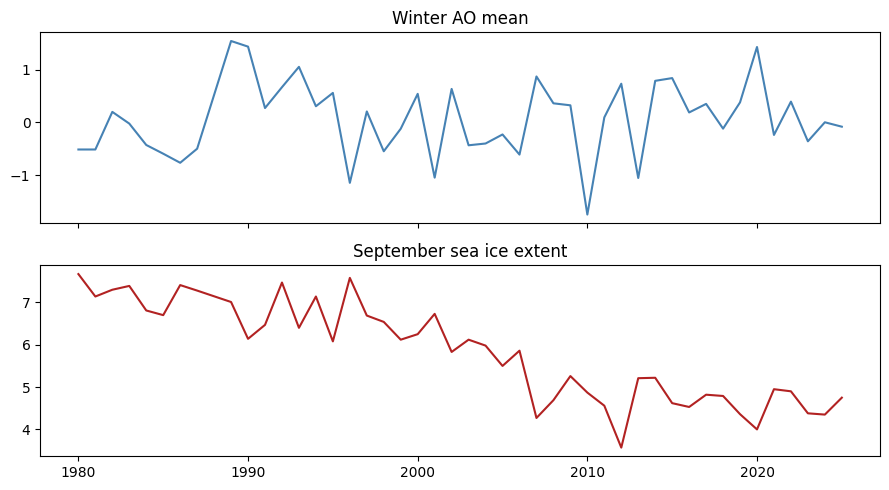

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(df['year'], df['winter_AO_mean'], color='steelblue')
axes[0].set_title('Winter AO mean')
axes[1].plot(df['year'], df['target_sept_extent'], color='firebrick')
axes[1].set_title('September sea ice extent')
plt.tight_layout()
plt.savefig('ao_and_ice_series.png', dpi=150)
plt.show()

## Stationarity check (ADF test)

The ADF test's starting assumption is that a series is not stationary, meaning it has
a trend or a unit root. A p value under 0.05 allows that assumption to be rejected,
meaning the series can be treated as stationary.

Expectation going in: target_sept_extent will most likely come back not stationary,
given the steady decline in the plot above. winter_AO_mean is less predictable and
could come back either way. Whichever way it lands decides what the next step needs
to do. If either series is not stationary, the Granger test needs to run on
differenced or detrended versions of the data rather than the raw series.

In [6]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: ADF stat = {result[0]:.3f}, p value = {result[1]:.3f}")
    print("  Stationary" if result[1] < 0.05 else "  Not stationary, has a trend or unit root")
    return result[1]

## Making the ice extent series stationary

winter_AO_mean is already stationary. target_sept_extent is not, which matches the
clear decline seen in the plot above. Running Granger causality on the raw ice
extent series would risk picking up the trend itself rather than any real link to
AO, so the series needs to be transformed first.

The standard fix here is first differencing, meaning each value is replaced by the
change from the previous year rather than the raw level. This removes a steady trend
without requiring any assumption about its shape. The differenced series is checked
with the ADF test again afterward, to confirm it is actually stationary before it
gets used in the causality test.

In [7]:
df['target_sept_extent_diff'] = df['target_sept_extent'].diff()

p_diff = adf_report(df['target_sept_extent_diff'], 'target_sept_extent_diff')

target_sept_extent_diff: ADF stat = -2.645, p value = 0.084
  Not stationary, has a trend or unit root


## Running the Granger causality test

Both series are now stationary, winter_AO_mean on its own and target_sept_extent
after differencing, so the test can run properly.

grangercausalitytests needs the two columns side by side, target first and the
candidate cause second, and a maximum number of lags to test. A few different lags
are checked rather than just one, since a real effect might show up one year out,
two years out, or not at all, and the test does not know in advance which one to
expect. maxlag is set to 3 here, since the record is only 45 years long and testing
too many lags on a short series starts to lose meaning.

Each lag reports an F test p value. A p value under 0.05 at a given lag means that
including AO's past values at that lag improved the prediction of ice extent by more
than would be expected by chance alone.

In [8]:
test_data = df[['target_sept_extent_diff', 'winter_AO_mean']].dropna()

results = grangercausalitytests(test_data, maxlag=3, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.7699  , p=0.3855  , df_denom=40, df_num=1
ssr based chi2 test:   chi2=0.8276  , p=0.3630  , df=1
likelihood ratio test: chi2=0.8198  , p=0.3652  , df=1
parameter F test:         F=0.7699  , p=0.3855  , df_denom=40, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.0848  , p=0.1387  , df_denom=37, df_num=2
ssr based chi2 test:   chi2=4.7332  , p=0.0938  , df=2
likelihood ratio test: chi2=4.4849  , p=0.1062  , df=2
parameter F test:         F=2.0848  , p=0.1387  , df_denom=37, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.8538  , p=0.1561  , df_denom=34, df_num=3
ssr based chi2 test:   chi2=6.7063  , p=0.0819  , df=3
likelihood ratio test: chi2=6.2111  , p=0.1018  , df=3
parameter F test:         F=1.8538  , p=0.1561  , df_denom=34, df_num=3


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## Reading the result

At every lag tested, one, two, and three years, the p value on AO's contribution
stayed well above 0.05. Granger causality, run this way, does not find evidence that
winter AO improves the prediction of September ice extent beyond what ice extent's
own past already provides.

This is worth sitting with rather than rushing past, since it does not match the
earlier PCMCI based result, where a permutation test found AO's contribution unlikely
to be due to chance. Before deciding what to make of that difference, one thing needs
checking first. The series used in this test, the differenced ice extent, was only
borderline stationary, at a p value of 0.084. A cleaner stationary version of the
series is checked next, before drawing any final conclusion.

## Checking the detrended version before drawing a conclusion

The Granger test above found no significant link at any lag. Before treating that as
the final answer, one loose end needs closing. The differenced series used in that
test was only borderline stationary, at a p value of 0.084, not clearly under 0.05.
A second way of removing the trend, fitting a straight line to ice extent and using
what is left over, is checked here for comparison. If it comes back more clearly
stationary, it is the more trustworthy version to draw a final conclusion from.

In [9]:
years = df['year'].values
extent = df['target_sept_extent'].values

trend_coeffs = np.polyfit(years, extent, deg=1)
trend_line = np.polyval(trend_coeffs, years)
df['target_sept_extent_detrended'] = extent - trend_line

p_lin = adf_report(df['target_sept_extent_detrended'], 'target_sept_extent_detrended')

target_sept_extent_detrended: ADF stat = -2.009, p value = 0.283
  Not stationary, has a trend or unit root


## Using the known 2007 break instead of a single straight line

The detrended series came back less stationary than the differenced series, not more,
which is the opposite of what a clean fix should do. A likely reason sits with the
Trend Break project's own finding, that a single straight line across the whole
record is misspecified, since the series behaves differently before and after 2007.
Subtracting one straight line from a broken series does not remove that structure
properly.

A piecewise version is tried here instead, using the same 2007 break point already
established in that earlier work, rather than searching for a new one. A separate
straight line is fit to each segment, before 2007 and from 2007 onward, and the
residuals from that piecewise fit are tested for stationarity in the same way as
before.

In [10]:
break_year = 2007

mask_before = years < break_year
mask_after = years >= break_year

piecewise_trend = np.zeros_like(extent, dtype=float)

coeffs_before = np.polyfit(years[mask_before], extent[mask_before], deg=1)
piecewise_trend[mask_before] = np.polyval(coeffs_before, years[mask_before])

coeffs_after = np.polyfit(years[mask_after], extent[mask_after], deg=1)
piecewise_trend[mask_after] = np.polyval(coeffs_after, years[mask_after])

df['target_sept_extent_piecewise_detrended'] = extent - piecewise_trend

p_piece = adf_report(df['target_sept_extent_piecewise_detrended'], 'target_sept_extent_piecewise_detrended')

target_sept_extent_piecewise_detrended: ADF stat = -3.336, p value = 0.013
  Stationary


## Comparing the three stationarity approaches side by side

Three ways of handling the trend in ice extent were tried, differencing, a single
straight line detrend, and a piecewise detrend built around the 2007 break. The p
values from each are worth putting side by side rather than only reading them one
at a time, since the size of the gap between the piecewise result and the other two
is itself part of the evidence for the break.

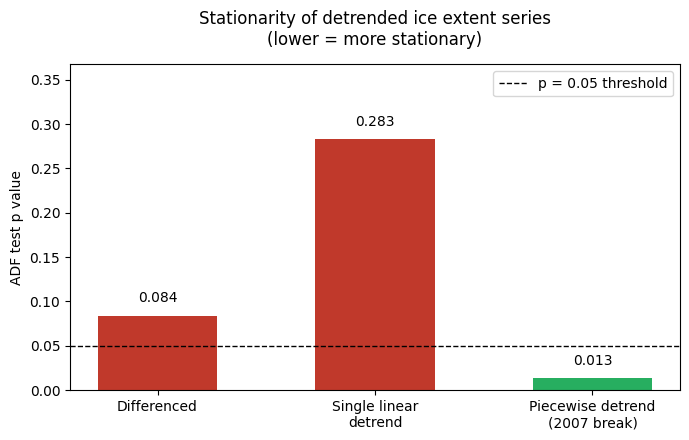

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
methods = ['Differenced', 'Single linear\ndetrend', 'Piecewise detrend\n(2007 break)']
pvals = [p_diff, p_lin, p_piece]
colors = ['#c0392b' if p >= 0.05 else '#27ae60' for p in pvals]
bars = ax.bar(methods, pvals, color=colors, width=0.55)
ax.axhline(0.05, color='black', linewidth=1, linestyle='--', label='p = 0.05 threshold')
for b, p in zip(bars, pvals):
    ax.text(b.get_x() + b.get_width()/2, p + 0.015, f'{p:.3f}', ha='center', fontsize=10)
ax.set_ylabel('ADF test p value')
ax.set_ylim(0, max(pvals) * 1.3)
ax.set_title('Stationarity of detrended ice extent series\n(lower = more stationary)', pad=14)
ax.legend()
plt.tight_layout()
plt.savefig('adf_comparison.png', dpi=150)
plt.show()

## What the piecewise trend actually looks like against the data

The p values above say the piecewise version fits best. It helps to see why,
rather than trust the number alone.

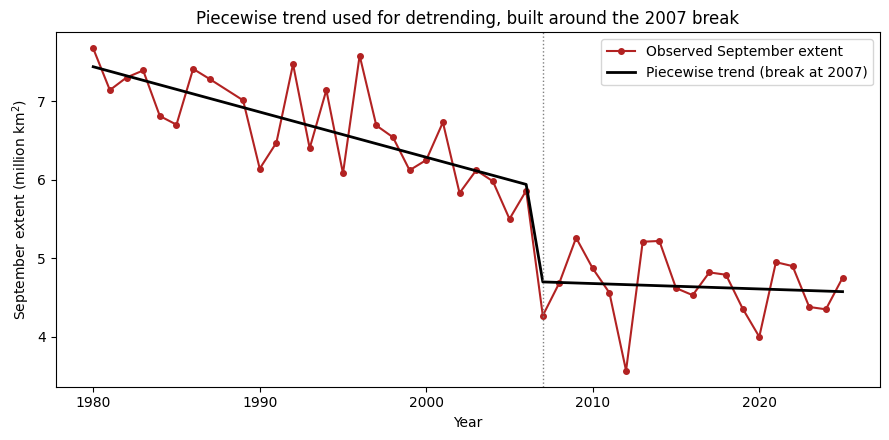

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(years, extent, 'o-', color='firebrick', label='Observed September extent', markersize=4)
ax.plot(years, piecewise_trend, color='black', linewidth=2, label='Piecewise trend (break at 2007)')
ax.axvline(2007, color='grey', linestyle=':', linewidth=1)
ax.set_ylabel('September extent (million km$^2$)')
ax.set_xlabel('Year')
ax.set_title('Piecewise trend used for detrending, built around the 2007 break')
ax.legend()
plt.tight_layout()
plt.savefig('piecewise_trend_fit.png', dpi=150)
plt.show()

## Final Granger test, using the piecewise detrended series

Of the three ways tried to make ice extent stationary, differencing, a single
straight line, and a piecewise fit around the 2007 break, only the piecewise version
came back clearly stationary. That is a second, independent piece of evidence for
the 2007 break, arrived at from a stationarity test rather than the original changepoint search. It is also the most trustworthy input for a Granger test, since the
other two versions left real nonstationarity behind.

The same Granger causality test as before is rerun here, this time against the
piecewise detrended series, to see whether the earlier null result holds up once the
input series is properly stationary rather than borderline.

In [13]:
test_data_piecewise = df[['target_sept_extent_piecewise_detrended', 'winter_AO_mean']].dropna()

results_piecewise = grangercausalitytests(test_data_piecewise, maxlag=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=0.9945  , df_denom=41, df_num=1
ssr based chi2 test:   chi2=0.0001  , p=0.9943  , df=1
likelihood ratio test: chi2=0.0001  , p=0.9943  , df=1
parameter F test:         F=0.0000  , p=0.9945  , df_denom=41, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2943  , p=0.2859  , df_denom=38, df_num=2
ssr based chi2 test:   chi2=2.9292  , p=0.2312  , df=2
likelihood ratio test: chi2=2.8337  , p=0.2425  , df=2
parameter F test:         F=1.2943  , p=0.2859  , df_denom=38, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.5262  , p=0.2248  , df_denom=35, df_num=3
ssr based chi2 test:   chi2=5.4943  , p=0.1390  , df=3
likelihood ratio test: chi2=5.1635  , p=0.1602  , df=3
parameter F test:         F=1.5262  , p=0.2248  , df_denom=35, df_num=3


## The final Granger result, visualised by lag

The p values above are worth seeing next to the 0.05 threshold directly, rather
than only as printed numbers, since it makes clear none of the three lags come
close to it.

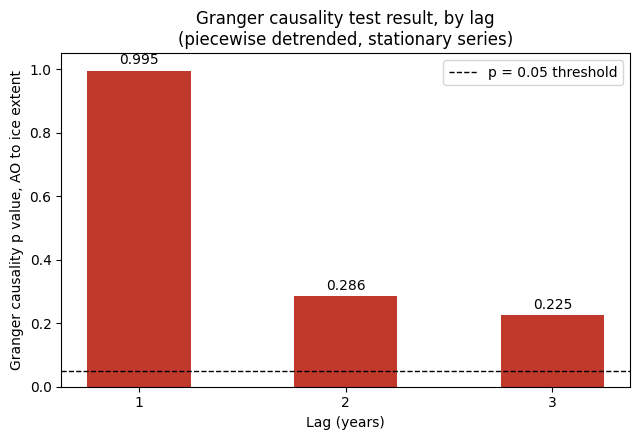

In [14]:
lags = [1, 2, 3]
pvals_granger = [results_piecewise[l][0]['ssr_ftest'][1] for l in lags]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bar_colors = ['#c0392b' if p >= 0.05 else '#27ae60' for p in pvals_granger]
ax.bar([str(l) for l in lags], pvals_granger, color=bar_colors, width=0.5)
ax.axhline(0.05, color='black', linewidth=1, linestyle='--', label='p = 0.05 threshold')
for i, p in enumerate(pvals_granger):
    ax.text(i, p + 0.02, f'{p:.3f}', ha='center', fontsize=10)
ax.set_xlabel('Lag (years)')
ax.set_ylabel('Granger causality p value, AO to ice extent')
ax.set_title('Granger causality test result, by lag\n(piecewise detrended, stationary series)')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('granger_pvalues_by_lag.png', dpi=150)
plt.show()

## Conclusion

Winter AO mean does not show a significant Granger causal link to September sea ice
extent, at lags of one, two, or three years, once the ice extent series is made
properly stationary. This was checked on three versions of the series, a differenced
version, a single straight line detrended version, and a piecewise detrended version
built around the 2007 break. Only the piecewise version came back clearly stationary,
and the null result held on that version as well as on the other two.

This does not match the earlier PCMCI based result, where a permutation test found
AO's contribution unlikely to be due to chance. That difference is worth stating
plainly rather than resolving in either direction. A few honest possibilities, not
mutually exclusive. Granger causality, even properly applied, is a linear test based
on a vector autoregression, and PCMCI is built to detect a wider range of dependency
structures using conditional independence testing rather than a linear fit, so it may
be picking up something real that a linear test misses. It is also possible the
earlier result partly reflects the small sample size, 45 winters, working in AO's
favour in that specific permutation test by chance, something a single permutation
test reduces but does not fully rule out. A third possibility is that the two tests
are simply asking different